In [1]:
import numpy as np                                            # ndarrays for gridded data
import pandas as pd                                           # DataFrames for tabular data
import matplotlib.pyplot as plt                               # for plotting
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator) # control of axes ticks
import seaborn as sns                                         # advanced plotting

In [2]:
def add_grid():
    plt.gca().grid(True, which='major',linewidth = 1.0); plt.gca().grid(True, which='minor',linewidth = 0.2) # add y grids
    plt.gca().tick_params(which='major',length=7); plt.gca().tick_params(which='minor', length=4)
    plt.gca().xaxis.set_minor_locator(AutoMinorLocator()); plt.gca().yaxis.set_minor_locator(AutoMinorLocator()) # turn on minor ticks

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/GeostatsGuy/GeoDataSets/master/spatial_nonlinear_MV_facies_v3.csv') # load data from Dr. Pyrcz's github repository
df.describe()

,Unnamed: 0,X,Y,Por,Perm,AI,Facies
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000
mean,227.829630,472.537037,522.622222,10.778590,406.286106,4292.475630,0.785185
std,141.514802,288.917266,277.643599,3.665004,147.891654,433.786043,0.411456
min,0.000000,0.000000,9.000000,3.135247,138.238177,3630.239427,0.000000
25%,102.250000,225.000000,309.000000,7.909297,309.663433,3981.691959,1.000000
50%,220.500000,475.000000,525.000000,10.557808,408.150631,4192.107297,1.000000
75%,336.000000,745.000000,769.000000,13.119702,495.549617,4491.224552,1.000000
max,499.000000,990.000000,999.000000,21.599413,798.263353,5701.203128,1.000000


The ndarray has a shape of (270,).


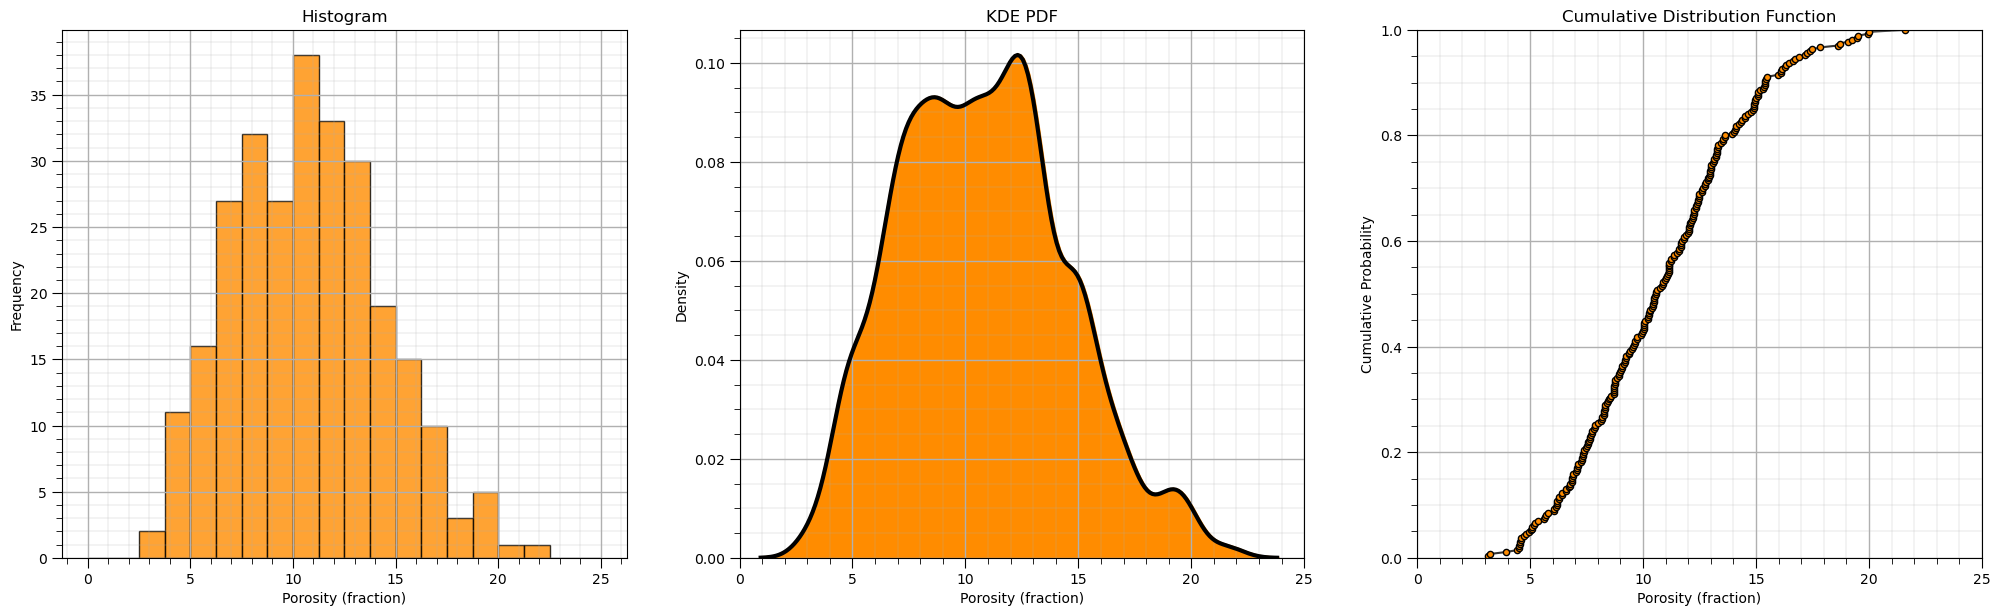

In [4]:
pormin = 0.0; pormax = 25.0

plt.subplot(131)
plt.hist(df['Por'].values,alpha=0.8,color="darkorange",edgecolor="black",bins=20,range=[pormin,pormax])
plt.title('Histogram'); plt.xlabel('Porosity (fraction)'); plt.ylabel("Frequency"); add_grid()

plt.subplot(132)
sns.kdeplot(x=df['Por'],color = 'black',alpha = 1.0,linewidth=3,bw_method=0.2,fill=False,zorder=10)
sns.kdeplot(x=df['Por'],color = 'darkorange',alpha = 1.0,linewidth=3,bw_method=0.2,fill=True,zorder=1)
plt.xlim([pormin,pormax]); add_grid()
plt.title('KDE PDF'); plt.xlabel('Porosity (fraction)'); plt.ylabel("Density")

plt.subplot(133)
por = df['Por'].copy(deep = True).values                 # make a deep copy of the feature from the DataFrame
print('The ndarray has a shape of ' + str(por.shape) + '.')

por = np.sort(por)                                            # sort the data in ascending order
n = por.shape[0]                                              # get the number of data samples
cprob = np.zeros(n)
for i in range(0,n):
    index = i + 1
    cprob[i] = index / n                                      # known upper tail
    # cprob[i] = (index - 1)/n                                # known lower tail
    # cprob[i] = (index - 1)/(n - 1)                          # known upper and lower tails
    # cprob[i] = index/(n+1)                                  # unknown tails  

plt.plot(por,cprob, alpha = 0.8, c = 'black',zorder=1) # plot piecewise linear interpolation
plt.scatter(por,cprob,s = 20, alpha = 1.0, c = 'darkorange', edgecolor = 'black',zorder=2) # plot the CDF points
plt.xlim([pormin,pormax]); plt.ylim([0.0,1.0]); add_grid()
plt.xlabel("Porosity (fraction)"); plt.ylabel("Cumulative Probability"); plt.title("Cumulative Distribution Function")

plt.subplots_adjust(left=0.0, bottom=0.0, right=3.0, top=1.1, wspace=0.2, hspace=0.2); plt.show()